# 06) Comparing MTG with YAMNet
- Using the pseudo labelled MTG data, we will create raw features from YAMNet
- From there, we will run XGBoost and compare performance from the PCA pipeline features
- While limited from just pseudo labels, we can see which pipeline can be more promising in predicting depth

## Library Imports

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

## Loading Data

In [7]:
mtg_pseudo = pd.read_csv('jamendo_pseudolabeled200_402.csv')
mtg_pseudo.shape

(200, 402)

In [9]:
X = mtg_pseudo.drop('depth', axis=1)
y = mtg_pseudo['depth']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)

In [6]:
depth = mtg_pseudo['depth']
depth.head(3)

0    0.369859
1    0.461100
2    0.512328
Name: depth, dtype: float64

In [4]:
YAMNet = pd.read_csv('yamnet_embeddings.csv')
YAMNet.head(3)

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0.031010,0.009804,0.201927,0.341958,0.047371,0.042084,0.008002,0.372051,0.042653,0.019957,...,0.013657,0.145741,0.057443,0.876964,0.068859,0.034818,0.023483,0.343449,0.049321,0.051373
1,0.013636,0.008263,0.351347,0.164860,0.021468,0.019399,0.031645,0.165750,0.018538,0.008247,...,0.005910,0.092519,0.026407,0.888910,0.031325,0.016000,0.012780,0.526118,0.017763,0.023586
2,0.032031,0.034451,0.559124,0.220291,0.048410,0.040856,0.002233,0.139612,0.044305,0.020093,...,0.013351,0.237030,0.055794,0.680860,0.067190,0.033838,0.025036,0.246374,0.141338,0.049789


In [5]:
YAMNet.insert(0, 'depth', depth)
YAMNet.head(3)

,depth,0,1,2,3,4,5,6,7,8,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0.369859,0.031010,0.009804,0.201927,0.341958,0.047371,0.042084,0.008002,0.372051,0.042653,...,0.013657,0.145741,0.057443,0.876964,0.068859,0.034818,0.023483,0.343449,0.049321,0.051373
1,0.461100,0.013636,0.008263,0.351347,0.164860,0.021468,0.019399,0.031645,0.165750,0.018538,...,0.005910,0.092519,0.026407,0.888910,0.031325,0.016000,0.012780,0.526118,0.017763,0.023586
2,0.512328,0.032031,0.034451,0.559124,0.220291,0.048410,0.040856,0.002233,0.139612,0.044305,...,0.013351,0.237030,0.055794,0.680860,0.067190,0.033838,0.025036,0.246374,0.141338,0.049789


## Data Split

In [6]:
X = YAMNet.drop('depth', axis=1)
y = YAMNet['depth']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)

## ML

In [10]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

### Baseline

In [8]:
y_pred_baseline = np.full_like(y_test, fill_value=np.mean(y_train), dtype=float)

base_r2 = r2_score(y_test, y_pred_baseline)
base_mae = mean_absolute_error(y_test, y_pred_baseline)
mse = mean_squared_error(y_test, y_pred_baseline)
base_rmse = np.sqrt(mse)

print("Depth baseline")
print(f"R2: {base_r2:.2}, RMSE: {base_rmse:.2}, MAE: {base_mae:.2}")

Depth baseline
R2: -0.029, RMSE: 0.16, MAE: 0.13


### Linear Regression

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
# creating model
lr_model = LinearRegression()

# training
lr_model.fit(X_train, y_train)

LinearRegression()

In [11]:
# prediction
predictions = lr_model.predict(X_test)

In [12]:
# metrics
r_2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
pcc, _ = pearsonr(y_test, predictions)

# improvements
improve_R2 = r_2 - base_r2
improve_RMSE = 1 - (rmse/base_rmse)
improve_MAE = 1 - (mae/base_mae)

In [13]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Baseline": [base_r2, base_rmse, base_mae],
    "Model": [r_2, rmse, mae,],
    "Δ (Model - Baseline)": [r_2 - base_r2, rmse - base_rmse, mae - base_mae],
    "% Improvement": [improve_R2, improve_RMSE, improve_MAE],
})

# formatting
df["Baseline"] = df["Baseline"].map(lambda x: f"{x:.3f}")
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")
df["Δ (Model - Baseline)"] = df["Δ (Model - Baseline)"].map(lambda x: f"{x:+.3f}")
df["% Improvement"] = df["% Improvement"].map(lambda x: "—" if pd.isna(x) else f"{x:+.0%}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

-----Model Performance-----

Metric Baseline  Model Δ (Model - Baseline) % Improvement
    R²   -0.029 -0.345               -0.316          -32%
  RMSE    0.159  0.182               +0.023          -14%
   MAE    0.134  0.129               -0.005           +4%

Model PCC: 0.658


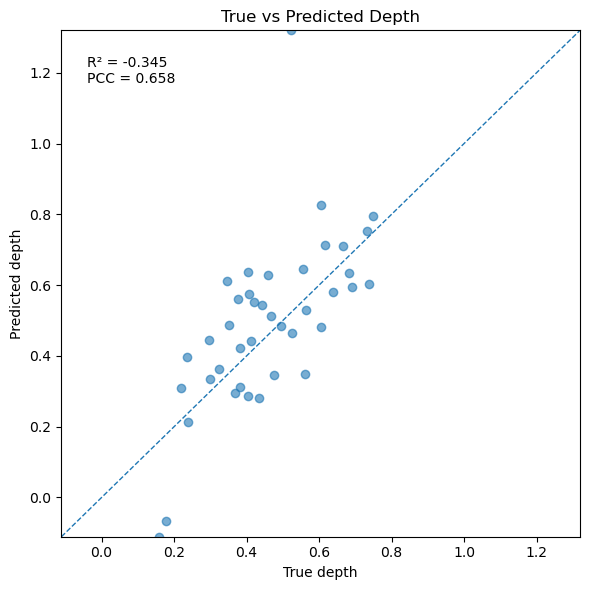

In [14]:
# Plotting R_2 and PCC scores

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6)

# 45° reference line
lims = [
    min(y_test.min(), predictions.min()),
    max(y_test.max(), predictions.max())
]
plt.plot(lims, lims, "--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True depth")
plt.ylabel("Predicted depth")
plt.title("True vs Predicted Depth")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r_2:.3f}\nPCC = {pcc:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

### Random Forest Regressor

In [11]:
from sklearn.ensemble import RandomForestRegressor

In [12]:
# creating model
rfr_model = RandomForestRegressor(random_state=12345)

# training
rfr_model.fit(X_train, y_train)

RandomForestRegressor(random_state=12345)

In [13]:
# prediction
predictions = rfr_model.predict(X_test)

In [15]:
# metrics
r_2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
pcc, _ = pearsonr(y_test, predictions)

# # improvements
# improve_R2 = r_2 - base_r2
# improve_RMSE = 1 - (rmse/base_rmse)
# improve_MAE = 1 - (mae/base_mae)

In [17]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Model": [r_2, rmse, mae],
})

# formatting
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

-----Model Performance-----

Metric Model
    R² 0.680
  RMSE 0.089
   MAE 0.072

Model PCC: 0.857


In [16]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Baseline": [base_r2, base_rmse, base_mae],
    "Model": [r_2, rmse, mae],
    "Δ (Model - Baseline)": [r_2 - base_r2, rmse - base_rmse, mae - base_mae],
    "% Improvement": [improve_R2, improve_RMSE, improve_MAE],
})

# formatting
df["Baseline"] = df["Baseline"].map(lambda x: f"{x:.3f}")
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")
df["Δ (Model - Baseline)"] = df["Δ (Model - Baseline)"].map(lambda x: f"{x:+.3f}")
df["% Improvement"] = df["% Improvement"].map(lambda x: "—" if pd.isna(x) else f"{x:+.0%}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

NameError: name 'base_r2' is not defined

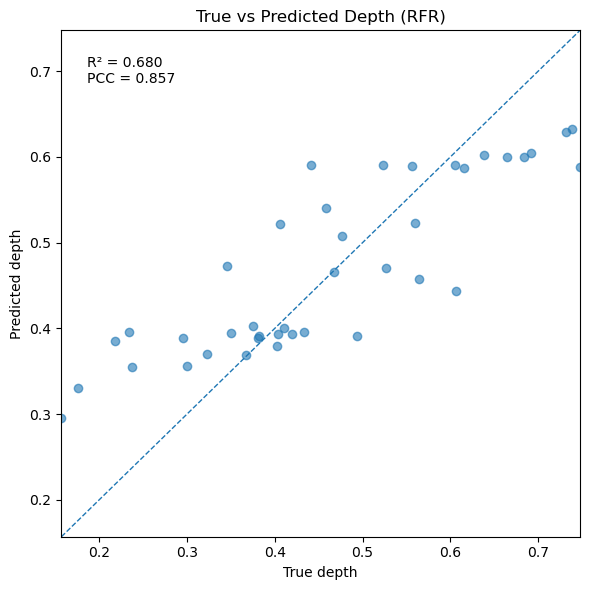

In [18]:
# Plotting R_2 and PCC scores

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6)

# 45° reference line
lims = [
    min(y_test.min(), predictions.min()),
    max(y_test.max(), predictions.max())
]
plt.plot(lims, lims, "--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True depth")
plt.ylabel("Predicted depth")
plt.title("True vs Predicted Depth (RFR)")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r_2:.3f}\nPCC = {pcc:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

# saving as JPEG
plt.savefig("true_pred_depth_RFR_PCA.jpg",
            dpi=300,
            bbox_inches="tight")

plt.tight_layout()
plt.show()

### XGBoost

In [19]:
import xgboost as xgb

In [20]:
# Define XGBRegressor model parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 3,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

# Instantiate XGBRegressor with the parameters
xgb = xgb.XGBRegressor(**params)

# Train the model
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [21]:
# prediction
predictions = xgb.predict(X_test)

In [23]:
# metrics
r_2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
pcc, _ = pearsonr(y_test, predictions)

# # improvements
# improve_R2 = r_2 - base_r2
# improve_RMSE = 1 - (rmse/base_rmse)
# improve_MAE = 1 - (mae/base_mae)

In [24]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Model": [r_2, rmse, mae],
})

# formatting
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

-----Model Performance-----

Metric Model
    R² 0.737
  RMSE 0.081
   MAE 0.065

Model PCC: 0.879


In [25]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Baseline": [base_r2, base_rmse, base_mae],
    "Model": [r_2, rmse, mae],
    "Δ (Model - Baseline)": [r_2 - base_r2, rmse - base_rmse, mae - base_mae],
    "% Improvement": [improve_R2, improve_RMSE, improve_MAE],
})

# formatting
df["Baseline"] = df["Baseline"].map(lambda x: f"{x:.3f}")
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")
df["Δ (Model - Baseline)"] = df["Δ (Model - Baseline)"].map(lambda x: f"{x:+.3f}")
df["% Improvement"] = df["% Improvement"].map(lambda x: "—" if pd.isna(x) else f"{x:+.0%}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

-----Model Performance-----

Metric Baseline Model Δ (Model - Baseline) % Improvement
    R²   -0.029 0.524               +0.553          +55%
  RMSE    0.159 0.108               -0.051          +32%
   MAE    0.134 0.091               -0.044          +32%

Model PCC: 0.760


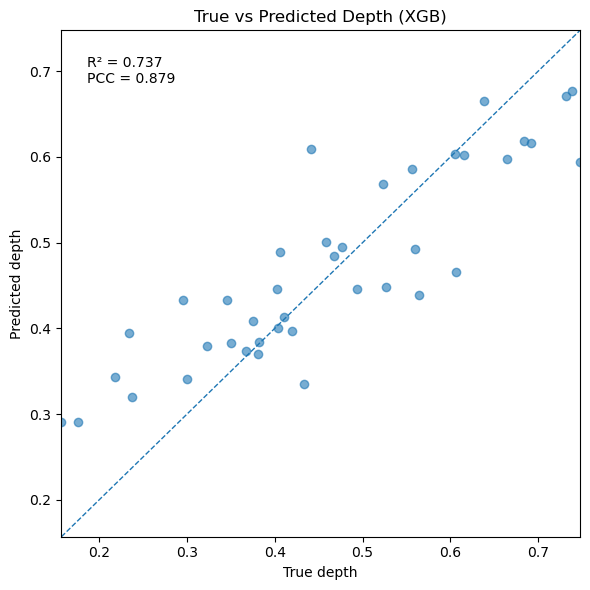

In [25]:
# Plotting R_2 and PCC scores

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6)

# 45° reference line
lims = [
    min(y_test.min(), predictions.min()),
    max(y_test.max(), predictions.max())
]
plt.plot(lims, lims, "--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True depth")
plt.ylabel("Predicted depth")
plt.title("True vs Predicted Depth (XGB)")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r_2:.3f}\nPCC = {pcc:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

# saving as JPEG
plt.savefig("true_pred_depth_XBR_PCA.jpg",
            dpi=300,
            bbox_inches="tight")

plt.tight_layout()
plt.show()

### Summary

- Using YAMNet, we extracted features from the MTG audio dataset used for the semi-supervised modeling
- We then compared to see if the YAMNet embedded features could perform better than the PCA pipeline created for the PSIC training model.
- Using XGBoost, we obtained a PCC = 0.76 and RMSE = 0.108, indicating a good performance compared to the PSIC pipelined training data.
- Next steps would be to replicate real depth values on the MTG data, comparing performance using the PCA pipeline, and possibly using YAMNet or another audio embedded features for depth prediction.